## STEP 1
Read the dataset and create labels '1' and '0' for botnet and normal/background traffic, respectively.


In [2]:
import os
import pandas as pd

# Directory containing the .flow files
directory = 'CTU_13/4_rbot'

# List to store individual dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.flow'):
        # Read the file into a dataframe
        df = pd.read_csv(os.path.join(directory, filename))  # Adjust the reading method if necessary
                
        # Append the dataframe to the list
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

combined_df.rename(columns={'Label': 'label'}, inplace=True)

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0, 'Background' -> 0
combined_df['label'] = combined_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x or 'Background' in x else x))

# Optionally reset the index if needed
combined_df.reset_index(drop=True, inplace=True)

print("Read dataset .flow and set label for it's samples")


Read dataset .flow and set label for it's samples


## STEP 2
Preprocess: Handel missing values and no numerical data \
In this section can specific custom list of features for input dataset 

In [3]:
import os
import yaml
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import re

def keep_features(df, features_to_keep):
    """
    Drop all columns from the DataFrame except for the specified features.
    
    Parameters:
    - df: pd.DataFrame, the input DataFrame
    - features_to_keep: list, list of column names to retain
    
    Returns:
    - pd.DataFrame with only the specified columns
    """
    # Ensure that the features_to_keep are in the DataFrame
    features_to_keep = [feature for feature in features_to_keep if feature in df.columns]
    
    # Return a DataFrame with only the specified features
    return df[features_to_keep]

# Function to preprocess each dataset
def preprocess_dataset(df):
    # Drop columns that contain only missing values
    df = df.dropna(axis=1, how='all')
    # Separate numeric and non-numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    
    # Check if DataFrame has either numeric or non-numeric columns
    if not numeric_cols.empty or not non_numeric_cols.empty:
        # Handle missing values for numeric data
        if not numeric_cols.empty:
            imputer_numeric = SimpleImputer(strategy='mean')
            df_numeric = pd.DataFrame(imputer_numeric.fit_transform(df[numeric_cols]), columns=numeric_cols)
        else:
            df_numeric = pd.DataFrame()  # Empty DataFrame for numeric data if no numeric columns exist
        
        # Handle missing values for non-numeric data
        if not non_numeric_cols.empty:
            imputer_non_numeric = SimpleImputer(strategy='most_frequent')
            df_non_numeric = pd.DataFrame(imputer_non_numeric.fit_transform(df[non_numeric_cols]), columns=non_numeric_cols)
            # Convert non-numeric features to one-hot encoding
            encoder = OneHotEncoder(drop='first')
            encoded = encoder.fit_transform(df_non_numeric)
            encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(non_numeric_cols))
        else:
            encoded_df = pd.DataFrame()  # Empty DataFrame for encoded non-numeric data if no non-numeric columns exist
        
        # Concatenate processed numeric and encoded non-numeric data
        df_preprocessed = pd.concat([df_numeric, encoded_df], axis=1)
        
        '''
        features = [
            'pRetran', 'Max', 'sMeanPktSz', 'SrcRetra', 'PCRatio',
            'SrcWin,SrcLoss', 'DstRate', 'SrcLoad', 'TcpOpt_MwsS  T', 'Load', 'DstLoad', 'TcpRtt', 'Flgs_ e g      ',
            'Flgs_ e d      ', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'State_S_',
            'Cause_Status', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'IdleTime', 'Dur', 'SrcPkts', 'Flgs_ e s      ',
            'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'DstWin', 'TotPkts', 'DstPkts', 'Flgs_ e *      ', 'Mean',
            'SrcBytes', 'State__SA', 'TotBytes', 'Cause_Start', 'dMeanPktSz', 'DstRetra', 'SynAck'
        ]
        
        '''
        features = [
            'sTtl', 'AckDat', 'TcpRtt', 'SynAck', 'IdleTime', 'SrcBytes', 
            'DstWin', 'SrcWin', 'TcpOpt_MwsS  T', 'Min', 'Dur', 'pLoss',
            'Flgs_ e s      ', 'State_S_', 'TotPkts', 'DstPkts'
        ]

        # Drop all columns except the ones in features_to_keep
        df_preprocessed = keep_features(df_preprocessed, features)  

        # Scale features
        scaler = MinMaxScaler()
        df_scaled = pd.DataFrame(scaler.fit_transform(df_preprocessed), columns=df_preprocessed.columns)

        return df_scaled
    else:
        return pd.DataFrame()
    
# Step 1: Separate the label column
X = combined_df.drop(columns=['label'])
y = combined_df['label']

pre_df = preprocess_dataset(X)

pre_df['label'] = y

print("Preprocess compelete")


Preprocess compelete


## STEP 3
Fit RandomForest model on Argus features with 5-fold cross validation

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
import numpy as np

# Assuming `df` is your DataFrame and 'label' is your target column

# Step 1: Separate features (X) and target (y)
X = pre_df.drop(columns=['label'])  # Drop the label column to get the features
y = pre_df['label']  # Target variable

# Step 2: Initialize the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)

# Step 3: Perform cross-validation
cv_results = cross_validate(clf, X, y, cv=5, scoring=['accuracy', 'f1_macro', 'recall_macro'], return_train_score=False)

# Print cross-validation results
print(f"Cross-Validation Accuracy: {np.mean(cv_results['test_accuracy']):.4f} ± {np.std(cv_results['test_accuracy']):.4f}")
print(f"Cross-Validation F1 Score: {np.mean(cv_results['test_f1_macro']):.4f} ± {np.std(cv_results['test_f1_macro']):.4f}")
print(f"Cross-Validation Recall: {np.mean(cv_results['test_recall_macro']):.4f} ± {np.std(cv_results['test_recall_macro']):.4f}")


Cross-Validation Accuracy: 0.9993 ± 0.0008
Cross-Validation F1 Score: 0.8737 ± 0.1878
Cross-Validation Recall: 0.8606 ± 0.1854


## STEP 4
CDR-MLC

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Read the DataFrame (Replace this with your DataFrame reading code)
df = pre_df

# List of features to compute incremental statistics
feature_list = ['SynAck', 'TcpRtt', 'AckDat']  # Replace with your actual features

import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

def analyze_features(df):
    """
    Analyzes features of the DataFrame based on statistical properties and diversity.
    
    Parameters:
    - df: pandas DataFrame containing the features to analyze.
    
    Returns:
    - stats_df_sorted: pandas DataFrame containing the statistical metrics for each feature, sorted by variance.
    """
    # Separate features (assuming the last column is the target variable)
    X = df.drop(columns=[df.columns[-1]])  # Drop the last column assuming it's the target
    
    # Initialize a DataFrame to hold statistical metrics
    stats_df = pd.DataFrame(index=X.columns)
    
    # Calculate statistical metrics
    stats_df['Mean'] = X.mean()
    stats_df['Median'] = X.median()
    stats_df['StdDev'] = X.std()
    stats_df['Variance'] = X.var()
    stats_df['Range'] = X.max() - X.min()
    stats_df['Skewness'] = X.apply(lambda x: skew(x.dropna()))
    stats_df['Kurtosis'] = X.apply(lambda x: kurtosis(x.dropna()))
    stats_df['Missing Values'] = X.isna().sum()
    
    # Sort by variance (or any other metric you prefer)
    stats_df_sorted = stats_df.sort_values(by='Variance', ascending=False)
    
    # Print the sorted statistics
    print("Feature Statistical Analysis and Diversity:")
    print(stats_df_sorted)
    
    return stats_df_sorted

# Example usage:
# df = pd.read_csv('your_data.csv')  # Load your DataFrame
# stats_df_sorted = analyze_features(df)


# Compute incremental statistics
def compute_incremental_stats(df, features):
    incremental_stats = pd.DataFrame(index=df.index)
    
    for feature in features:
        incremental_stats[f'{feature}_mean'] = df[feature].expanding().mean()
        incremental_stats[f'{feature}_median'] = df[feature].expanding().median()
        incremental_stats[f'{feature}_std'] = df[feature].expanding().std()
        #incremental_stats[f'{feature}_max'] = df[feature].expanding().max()
        #incremental_stats[f'{feature}_min'] = df[feature].expanding().min()
    
    return incremental_stats

# Compute incremental statistics for the features
incremental_stats = compute_incremental_stats(df, feature_list)

# Fill NaN values in incremental statistics with 0
incremental_stats.fillna(0, inplace=True)

# Add incremental statistics to the original DataFrame
df_with_stats = pd.concat([df, incremental_stats], axis=1)

# Standardize the incremental features before clustering
incremental_feature_cols = [col for col in df_with_stats.columns if col.endswith(('mean', 'median', 'std'))]

X = df_with_stats[incremental_feature_cols]

#analyze_features(X)

# Fill NaN values in the features (if any) with 0
X = X.fillna(0)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
n_clusters = 3
while n_clusters > 1:
    # Perform MiniBatch KMeans clustering
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    print("test1")
    # Add cluster labels to the DataFrame
    df_with_stats['cluster'] = clusters

    # Remove incremental features
    df_final = df_with_stats.drop(columns=incremental_feature_cols)

    # Initialize dictionary to store classifiers and results
    classifiers = {}
    results = {}

    # Train and evaluate Random Forest Classifier for each cluster with cross-validation
    min_len_threshold = len(X)
    max_len_threshold = 0
    print(f"test2 {min_len_threshold} - {max_len_threshold}")
    for i in range(n_clusters):
        # Select data for the current cluster
        cluster_data = df_final[df_final['cluster'] == i]
        if len(cluster_data) < min_len_threshold:
            min_len_threshold = len(cluster_data)
        if len(cluster_data) >= max_len_threshold:
            max_len_threshold = len(cluster_data)
    print(f"test3 {min_len_threshold} - {max_len_threshold}")

    if max_len_threshold > 5*min_len_threshold:
        n_clusters -= 1
        print(f"Data cluster is imbalance clusters count {clusters}")
        continue

    for i in range(n_clusters):
        # Select data for the current cluster
        cluster_data = df_final[df_final['cluster'] == i]
    
        if len(cluster_data) == 0:
            print(f"Cluster {i} has no data. Skipping.")
            continue
        
        # Separate features and target
        X_cluster = cluster_data.drop(columns=['label'])
        y_cluster = cluster_data['label']
        
        # Check if there is enough data to perform cross-validation
        if len(X_cluster) < 5:
            print(f"Not enough data for cross-validation in cluster {i}.")
            continue
        
        # Initialize Random Forest Classifier
        clf = RandomForestClassifier(n_estimators=10, random_state=42)
        
        # Perform cross-validation
        cv_results = cross_validate(clf, X_cluster, y_cluster, cv=5, scoring=['accuracy', 'f1_macro', 'recall_macro'], return_train_score=False)
        
        # Fit the model on the entire cluster data for confusion matrix
        clf.fit(X_cluster, y_cluster)
        
        # Predict on the same data to compute confusion matrix
        y_pred = clf.predict(X_cluster)
        
        # Compute confusion matrix
        cm = confusion_matrix(y_cluster, y_pred)
        
        # Store the classifier and results
        classifiers[i] = clf
        results[i] = {
            'cv_accuracy': np.mean(cv_results['test_accuracy']),
            'cv_f1_score': np.mean(cv_results['test_f1_macro']),
            'cv_recall': np.mean(cv_results['test_recall_macro']),
            'confusion_matrix': cm,
            'classification_report': classification_report(y_cluster, y_pred)
        }
        clusters = 0

# Print the results for each cluster
for i, result in results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance:")
    print(f"Cross-Validation Accuracy: {result['cv_accuracy']:.4f}")
    print(f"Cross-Validation F1 Score: {result['cv_f1_score']:.4f}")
    print(f"Cross-Validation Recall: {result['cv_recall']:.4f}")
    print("\nConfusion Matrix:")
    print(result['confusion_matrix'])
    print("\nClassification Report:")
    print(result['classification_report'])


test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 273182 - 480011
test1
test2 1121076 - 0
test3 2731

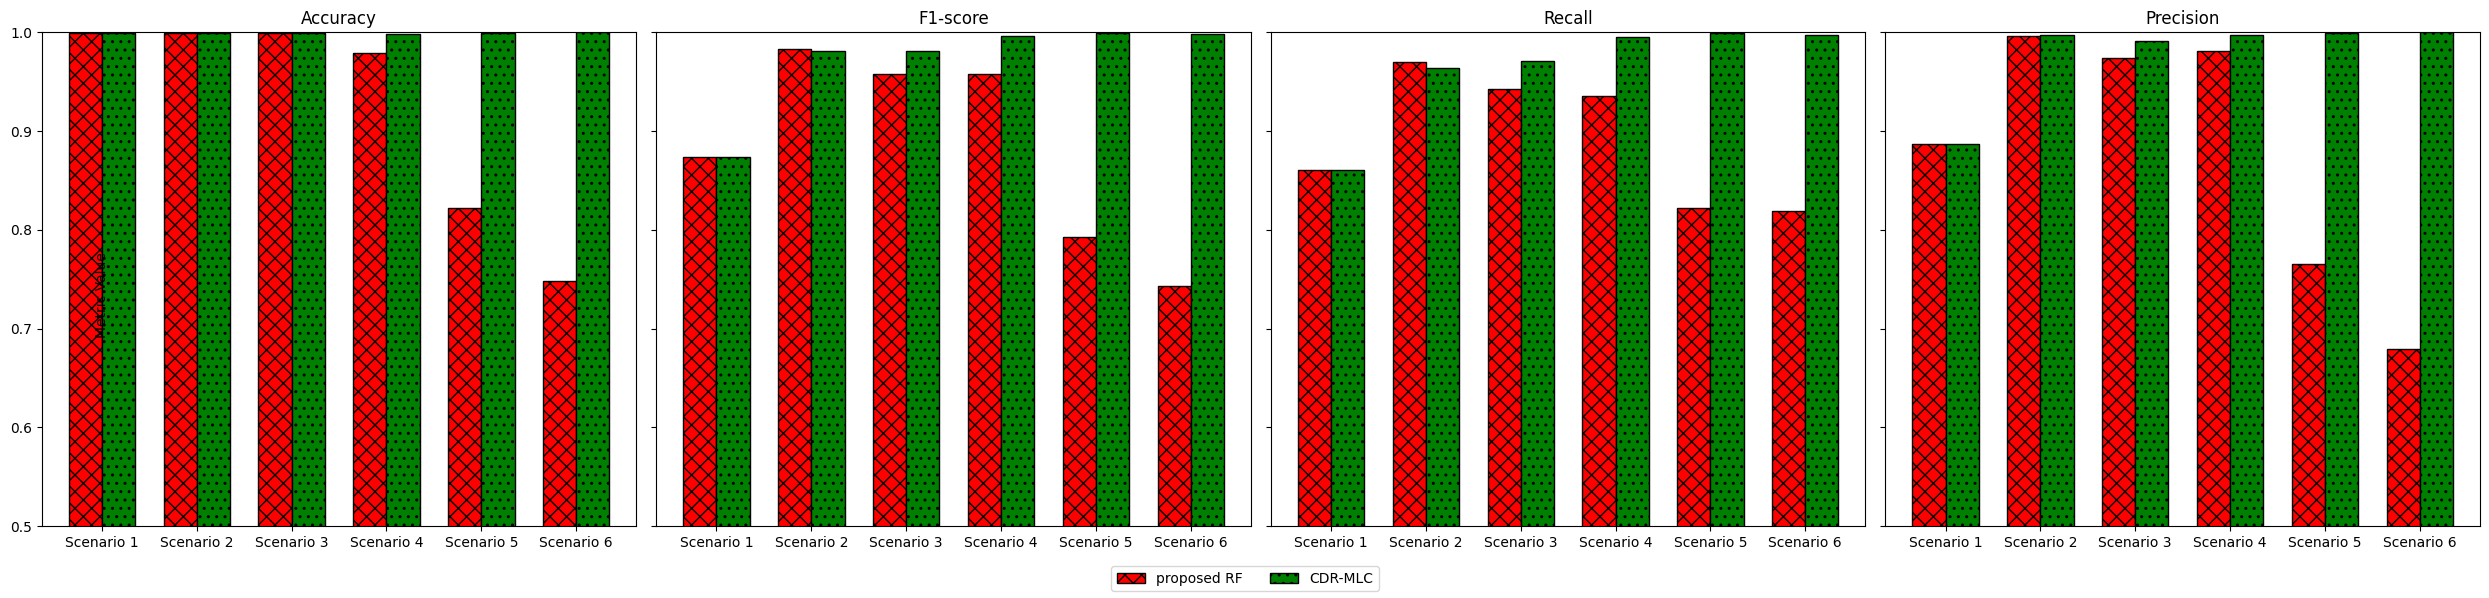

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each scenario
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4', 'Scenario 5', 'Scenario 6']
accuracy = {
    'ProposedRF': [0.9993, 0.9992, 0.9989, 0.9790, 0.8221, 0.7481],
    'CDR-MLC': [0.9993, 0.9991, 0.9996, 0.9980, 0.9994, 0.9998]
}
f_score = {
    'ProposedRF': [0.8737, 0.9828, 0.9581, 0.9579, 0.7929, 0.7429],
    'CDR-MLC': [0.8737, 0.9806, 0.9809, 0.9964, 0.9994, 0.9986]
}
recall = {
    'ProposedRF': [0.8606, 0.9697, 0.9427, 0.9358, 0.8224, 0.8191],
    'CDR-MLC': [0.8606, 0.9643, 0.9712, 0.9957, 0.9994, 0.9973]
}
precision = {
    'ProposedRF': [0.8872, 0.9963, 0.9740, 0.9811, 0.7654, 0.6797],
    'CDR-MLC': [0.8872, 0.9975, 0.9908, 0.9971, 0.9994, 0.9999]
}

# Plotting all four metrics horizontally
fig, axs = plt.subplots(1, 4, figsize=(25, 6), sharey=True)  # 1 row, 4 columns layout

# Bar width for each plot
bar_width = 0.35
index = np.arange(len(scenarios))

# Plot for Accuracy
bar1 = axs[0].bar(index, accuracy['ProposedRF'], bar_width, label='proposed RF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[0].bar(index + bar_width, accuracy['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[0].set_title('Accuracy')
axs[0].set_xticks(index + bar_width / 2)
axs[0].set_xticklabels(scenarios)
axs[0].set_ylim(0.5, 1)

# Plot for F-score
bar1 = axs[1].bar(index, f_score['ProposedRF'], bar_width, label='proposed RF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[1].bar(index + bar_width, f_score['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[1].set_title('F1-score')
axs[1].set_xticks(index + bar_width / 2)
axs[1].set_xticklabels(scenarios)
axs[1].set_ylim(0.5, 1)

# Plot for Recall
bar1 = axs[2].bar(index, recall['ProposedRF'], bar_width, label='proposed RF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[2].bar(index + bar_width, recall['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[2].set_title('Recall')
axs[2].set_xticks(index + bar_width / 2)
axs[2].set_xticklabels(scenarios)
axs[2].set_ylim(0.5, 1)

# Plot for Precision
bar1 = axs[3].bar(index, precision['ProposedRF'], bar_width, label='proposed RF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[3].bar(index + bar_width, precision['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[3].set_title('Precision')
axs[3].set_xticks(index + bar_width / 2)
axs[3].set_xticklabels(scenarios)
axs[3].set_ylim(0.5, 1)

# Set y-label for the entire figure
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical')

# Adding a common legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make space for the legend
plt.show()
